# **Análise de Sensibilidade — Clusterização de eventos sísmicos**

Este notebook avalia a robustez do pipeline desenvolvido em `exploratory_analysis.ipynb`, com foco na zona de subducção da **Indonésia/Sumatra** — região selecionada por sua alta densidade de eventos (M ≥ 4.5) e coerência tectônica, que permite investigar dinâmica sísmica regional sem o ruído introduzido pela mistura de zonas geologicamente distintas.

Investigamos como diferentes escolhas para o tamanho da janela de extração de features e para o passo da janela deslizante afetam a estrutura dos clusters e a dinâmica temporal coarse-grained do sistema. A análise busca responder a duas questões centrais:

- **Os clusters emergentes podem ser interpretados como regimes físicos distintos?**
- **A dinâmica entre esses regimes pode ser descrita, em primeira aproximação, por um processo Markoviano?**

## **1. Imports**

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
from itertools import product
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from tensorflow import keras
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc, f1_score, accuracy_score
)
from sklearn.model_selection import train_test_split

ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

I0000 00:00:1773599666.266130   15838 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773599666.266594   15838 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773599666.292737   15838 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773599667.066124   15838 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

In [2]:
from src.data_ingestion.io_usgs      import load_catalog_parquet
from src.window_features.schemas     import WindowConfig
from src.window_features.builder     import build_features_df
from src.pca_pipeline.prepare        import prepare_X
from src.pca_pipeline.pca_utils      import fit_pca

## **2. Carregamento dos dados**

In [9]:
db_path = Path.cwd().parent / "data" / "seismic.db"
conn = sqlite3.connect(db_path)

# Regional filter
df_raw = pd.read_sql("""
    SELECT * FROM earthquakes
    WHERE latitude BETWEEN -10 AND 10
      AND longitude BETWEEN 95 AND 140
""", conn)
conn.close()

df_raw["time"] = pd.to_datetime(df_raw["time"], format="ISO8601")
print(f"Indonésia/Sumatra: {len(df_raw)} eventos")

Indonésia/Sumatra: 3428 eventos


In [10]:
REGIONS = {
    "japan":     (30, 50, 130, 155),
    "alaska":    (50, 65, -180, -120),
    "nazca":     (-40, -10, -80, -65),
    "indonesia": (-10, 10, 95, 140),
}

def load_region(region_key: str) -> pd.DataFrame:
    lat_min, lat_max, lon_min, lon_max = REGIONS[region_key]
    conn = sqlite3.connect(db_path)
    df = pd.read_sql("""
        SELECT * FROM earthquakes
        WHERE latitude BETWEEN ? AND ?
          AND longitude BETWEEN ? AND ?
    """, conn, params=(lat_min, lat_max, lon_min, lon_max))
    conn.close()
    df["time"] = pd.to_datetime(df["time"], format="ISO8601")
    return df

df_raw = load_region("indonesia")

## **3. Configurações de janela**

Duas dimensões são varridas:

- **Tamanho da janela** (`window_size`): quanto tempo cada janela cobre
- **Passo** (`step_size`): intervalo entre janelas consecutivas

A razão `step / window` determina o grau de sobreposição. Quando `step = window` (sem sobreposição), cada evento pertence a exatamente uma janela — o que destrói a continuidade temporal da série e degrada o sinal. Quando `step < window`, janelas consecutivas compartilham eventos, preservando a memória temporal do sistema.



In [11]:
CONFIGS = [
    # --- 8h --- #
    ("8h",  "1h"),   
    ("8h",  "2h"),   
    ("8h",  "4h"),   
    ("8h",  "8h"),   
    # --- 12h --- #
    ("12h", "1h"),   
    ("12h", "2h"),   
    ("12h", "6h"),   
    ("12h", "12h"),  
    # --- 24h --- #
    ("24h", "1h"),   
    ("24h", "6h"),   
    ("24h", "12h"),  
    ("24h", "24h"),  
]

rows = []
for w, s in CONFIGS:
    tw = pd.Timedelta(w).total_seconds() / 3600
    ts = pd.Timedelta(s).total_seconds() / 3600
    overlap = (1 - ts / tw) * 100
    rows.append({"Window": w, "Step": s, "Overlap (%)": f"{overlap:.0f}%"})

display(pd.DataFrame(rows))

,Window,Step,Overlap (%)
0,8h,1h,88%
1,8h,2h,75%
2,8h,4h,50%
3,8h,8h,0%
4,12h,1h,92%
5,12h,2h,83%
6,12h,6h,50%
7,12h,12h,0%
8,24h,1h,96%
9,24h,6h,75%


## **4. Pipeline de extração e clusterização**

Para cada configuração, executamos o pipeline completo:

- **Extração de features por janela temporal**  
- **PCA para redução de dimensionalidade**  
- **KMeans com k=2**  
- **Cálculo do silhouette score global e por cluster**  
- **Estimação da Matriz de Transição de Markov**

In [12]:
def relabel_by_activity(labels: np.ndarray, features_df: pd.DataFrame,
                         anchor_col: str = 'rate_per_day') -> np.ndarray:
    """
    Reordena os rótulos do KMeans de forma que o cluster com maior
    valor médio de anchor_col receba sempre o rótulo mais alto.
    """
    df_tmp = features_df.copy()
    df_tmp['_label'] = labels
    means = df_tmp.groupby('_label')[anchor_col].mean()
    # Mapeia: menor média → 0, maior média → 1 (para k=2)
    rank_map = {old: new for new, old in enumerate(means.sort_values().index)}
    return np.array([rank_map[l] for l in labels])

In [13]:
COLS_TO_REMOVE = [
    'n_earthquakes', 'frac_earthquake',
    'dt_mean_s', 'dt_std_s', 'dt_p95_s',
    'lat_mean', 'lon_mean',
]

N_COMPONENTS = 11

def build_markov_matrix(labels: np.ndarray) -> np.ndarray:
    """Estima a matriz de transição empírica T[i,j] = P(S_{t+1}=j | S_t=i)."""
    n_states = len(np.unique(labels))
    T = np.zeros((n_states, n_states))
    for t in range(len(labels) - 1):
        T[labels[t], labels[t + 1]] += 1
    row_sums = T.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # evita divisão por zero
    return T / row_sums


def run_pipeline(df_raw, window_size: str, step_size: str, min_events: int = 1,
                 n_pca: int = 10, k: int = 2, random_state: int = 42):
    """
    Executa o pipeline completo para uma dada configuração de janela.
    Retorna um dict com features, labels, silhouette e matriz de Markov.
    """
    
    # Build pseudo-time series
    window_cfg = WindowConfig(
        window_size=pd.Timedelta(window_size), 
        step_size=pd.Timedelta(step_size),
        min_events=min_events
    )
    features_df = build_features_df(df_raw, window_cfg)

    # PCA analysis
    X_scaled, feature_names, _, _ = prepare_X(features_df, cols_to_remove=COLS_TO_REMOVE)
    pca, X_pca = fit_pca(X_scaled, n_components=n_pca)

    # KMeans analysis
    km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
    labels = km.fit_predict(X_pca)
    labels = relabel_by_activity(labels, features_df)

    sil_global = silhouette_score(X_pca, labels)
    markov = build_markov_matrix(labels)

    return {
        "window_size": window_size,
        "step_size": step_size,
        "n_windows": len(features_df),
        "labels": labels,
        "X_pca": X_pca,
        "silhouette": sil_global,
        "markov": markov,
        "class_counts": np.bincount(labels),
        "features_df": features_df
    }

In [14]:
results = {}
for (w, s) in CONFIGS:
    key = f"{w}_step{s}"
    print(f"Rodando: window={w}, step={s} ...", end=" ")
    results[key] = run_pipeline(df_raw, window_size=w, step_size=s)
    r = results[key]
    print(f"→ {r['n_windows']:,} janelas | silhouette={r['silhouette']:.3f}")

Rodando: window=8h, step=1h ... → 14,600 janelas | silhouette=0.336
Rodando: window=8h, step=2h ... → 7,293 janelas | silhouette=0.338
Rodando: window=8h, step=4h ... → 3,654 janelas | silhouette=0.344
Rodando: window=8h, step=8h ... → 1,843 janelas | silhouette=0.349
Rodando: window=12h, step=1h ... → 18,299 janelas | silhouette=0.273
Rodando: window=12h, step=2h ... → 9,154 janelas | silhouette=0.275
Rodando: window=12h, step=6h ... → 3,038 janelas | silhouette=0.271
Rodando: window=12h, step=12h ... → 1,522 janelas | silhouette=0.266
Rodando: window=24h, step=1h ... → 23,802 janelas | silhouette=0.205
Rodando: window=24h, step=6h ... → 3,965 janelas | silhouette=0.204
Rodando: window=24h, step=12h ... → 1,987 janelas | silhouette=0.202
Rodando: window=24h, step=24h ... → 996 janelas | silhouette=0.198


## **5. Separação física entre os clusters**

Aqui geramos sumários para cada configuração de janela, buscando responder se a separação entre os clusters possui algum alicerce em features físicas.

In [15]:
def physical_summary(results: dict, cols_phys: list) -> dict:
    """
    Retorna o summary físico por cluster para cada config.
    """
    summaries = {}
    for key, r in results.items():
        df_feat = r['features_df'].copy()
        df_feat['cluster'] = r['labels']
        summary = df_feat.groupby('cluster')[cols_phys].mean().round(3)
        counts = df_feat['cluster'].value_counts().sort_index().rename('count')
        summaries[key] = {'mean': summary, 'counts': counts}
    return summaries

cols_phys = [
    'rate_per_day', 'energy_sum_log10',
    'mag_max', 'spread_km_mean'
]

phys_summaries = physical_summary(results, cols_phys)

for key, s in phys_summaries.items():
    print(f"\n{'='*50}\n  {key}\n{'='*50}")
    display(s['mean'])
    print(s['counts'])


  8h_step1h


,rate_per_day,energy_sum_log10,mag_max,spread_km_mean
cluster,,,,
0,4.075,7.235,4.793,58.504
1,11.194,7.873,5.119,1019.617


cluster
0    11412
1     3188
Name: count, dtype: int64

  8h_step2h


,rate_per_day,energy_sum_log10,mag_max,spread_km_mean
cluster,,,,
0,4.075,7.236,4.793,62.188
1,11.348,7.886,5.128,1025.438


cluster
0    5728
1    1565
Name: count, dtype: int64

  8h_step4h


...

cluster
0    2475
1    1490
Name: count, dtype: int64

  24h_step12h


,rate_per_day,energy_sum_log10,mag_max,spread_km_mean
cluster,,,,
0,2.428,7.472,4.883,296.940
1,5.155,8.048,5.204,1174.297


cluster
0    1244
1     743
Name: count, dtype: int64

  24h_step24h


,rate_per_day,energy_sum_log10,mag_max,spread_km_mean
cluster,,,,
0,2.385,7.482,4.890,295.616
1,5.147,8.034,5.193,1167.928


cluster
0    615
1    381
Name: count, dtype: int64


Mediante os sumários, obtemos a primeira evidência de que existem dois regimes sísmicos fisicamente distintos na zona de subducção da Indonésia: um regime **basal**, associado ao cluster **0** (baixa taxa diária e sismicidade mais localizada), e um regime **ativo**, associado ao cluster **1** (maior taxa sísmica e atividade espacialmente dispersa ao longo de cerca de 1000 km da zona de subducção).

A divisão em dois macroestados fisicamente distintos não parece ser um artefato da configuração das janelas, uma vez que essa estrutura se preserva em todo o grid de configurações testado.

## **6. Silhouette score por configuração**

O silhouette score mede a coesão interna e a separação entre clusters. Valores próximos de 1 indicam clusters bem definidos e separados. Aqui verificamos se a qualidade da clusterização se mantém em diferentes escalas temporais.

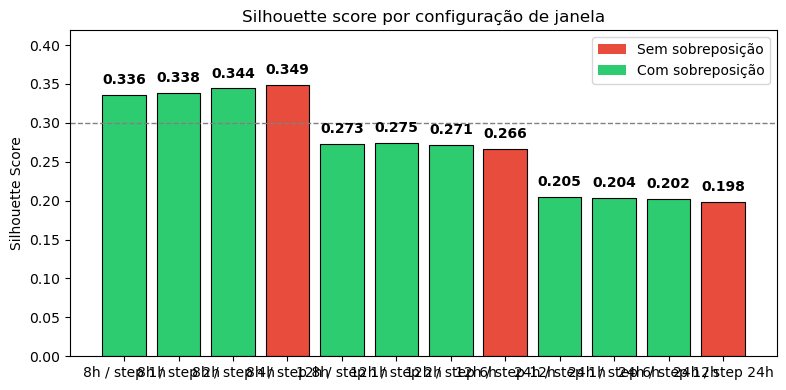

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

keys     = list(results.keys())
labels_x = [f"{results[k]['window_size']} / step {results[k]['step_size']}" for k in keys]
sils     = [results[k]['silhouette'] for k in keys]

def is_no_overlap(r):
    return pd.Timedelta(r['step_size']) >= pd.Timedelta(r['window_size'])

colors = ['#e74c3c' if is_no_overlap(results[k]) else '#2ecc71' for k in keys]

bars = ax.bar(labels_x, sils, color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(0.3, color='gray', linestyle='--', linewidth=1)
ax.set_ylim(0, max(sils) * 1.2)
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette score por configuração de janela')

for bar, val in zip(bars, sils):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Sem sobreposição'),
                   Patch(facecolor='#2ecc71', label='Com sobreposição')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('../figures/silhouette_by_config.png', dpi=150)
plt.show()

## **7. Dinâmica Markoviana**

### **7.1 Matrizes de transição**

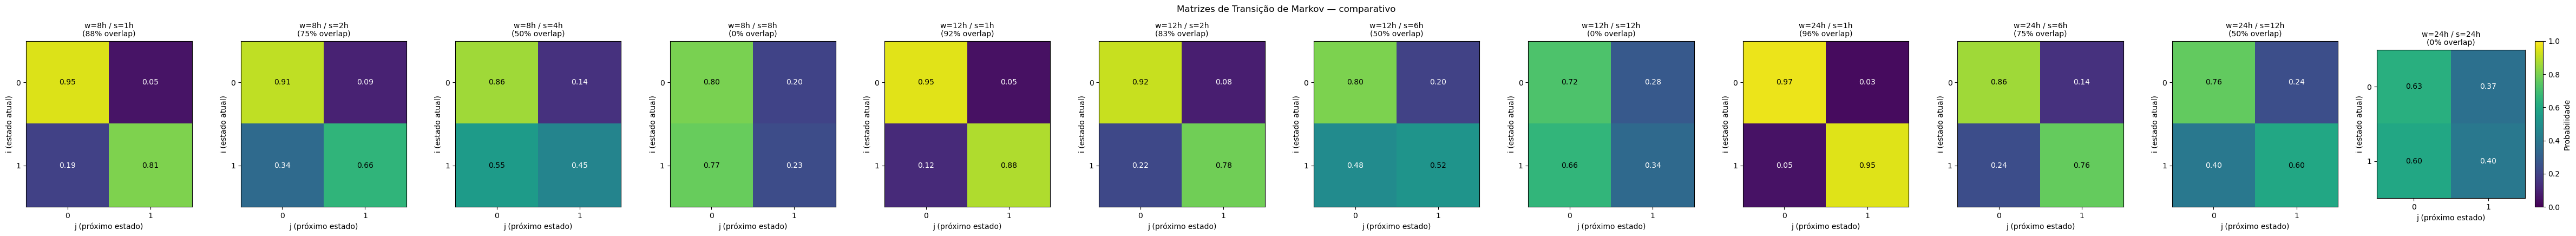

In [17]:
fig, axes = plt.subplots(1, len(CONFIGS), figsize=(4 * len(CONFIGS), 4), squeeze=False)
axes = axes[0]

for ax, (w, s) in zip(axes, CONFIGS):
    key = f"{w}_step{s}"
    T = results[key]['markov']
    n_states = T.shape[0]  # ← dinâmico
    tw = pd.Timedelta(w).total_seconds() / 3600
    ts = pd.Timedelta(s).total_seconds() / 3600
    overlap = (1 - ts / tw) * 100
    im = ax.imshow(T, vmin=0, vmax=1, cmap='viridis')
    ax.set_title(f'w={w} / s={s}\n({overlap:.0f}% overlap)', fontsize=10)
    ax.set_xlabel('j (próximo estado)')
    ax.set_ylabel('i (estado atual)')
    ax.set_xticks(range(n_states)); ax.set_yticks(range(n_states))  # ← dinâmico
    for i in range(n_states):      # ← dinâmico
        for j in range(n_states):  # ← dinâmico
            ax.text(j, i, f'{T[i,j]:.2f}', ha='center', va='center',
                    color='white' if T[i,j] < 0.5 else 'black', fontsize=10)

plt.colorbar(im, ax=axes[-1], label='Probabilidade')
plt.suptitle('Matrizes de Transição de Markov — comparativo', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/markov_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

O **cluster 0** constitui o regime mais claramente metaestável do sistema, enquanto o **cluster 1** exibe um caráter metaestável apenas em configurações com maior resolução temporal e maior sobreposição entre janelas, tornando-se progressivamente mais transitório à medida que a sobreposição é reduzida.

Fisicamente, esse comportamento pode indicar que o regime ativo se manifesta como uma excitação temporária sobre um fundo basal persistente.

### **7.2 Dwell time**

Mediante as matrizes de transição, podemos aferir o tempo de permanência em cada macroestado (**Dwell time**), para cada configuração de janelas:


  8h_step1h


,empirical_mean_h,empirical_median_h,empirical_std_h,P_ii,tau_theoretical_h
cluster,,,,,
0,18.6,13.0,18.4,0.946280,18.615008
1,5.2,5.0,3.7,0.807403,5.192182


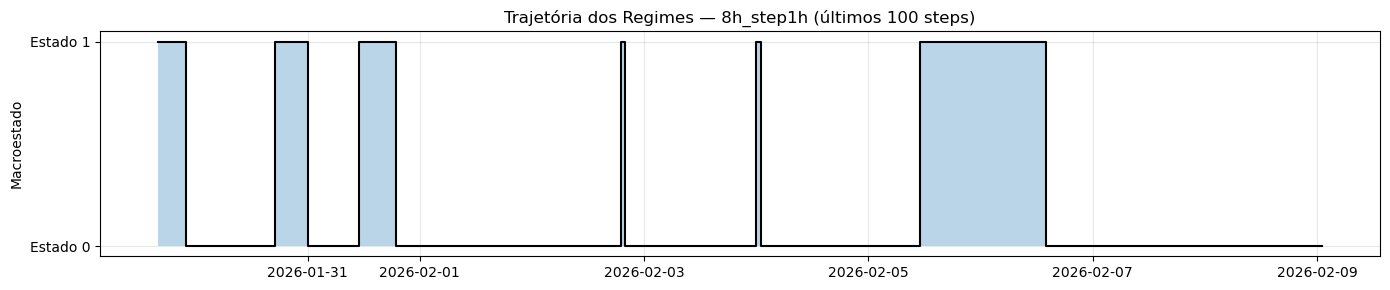


  8h_step2h


,empirical_mean_h,empirical_median_h,empirical_std_h,P_ii,tau_theoretical_h
cluster,,,,,
0,21.3,14.0,20.3,0.906234,21.329609
1,5.8,6.0,3.8,0.656230,5.817844


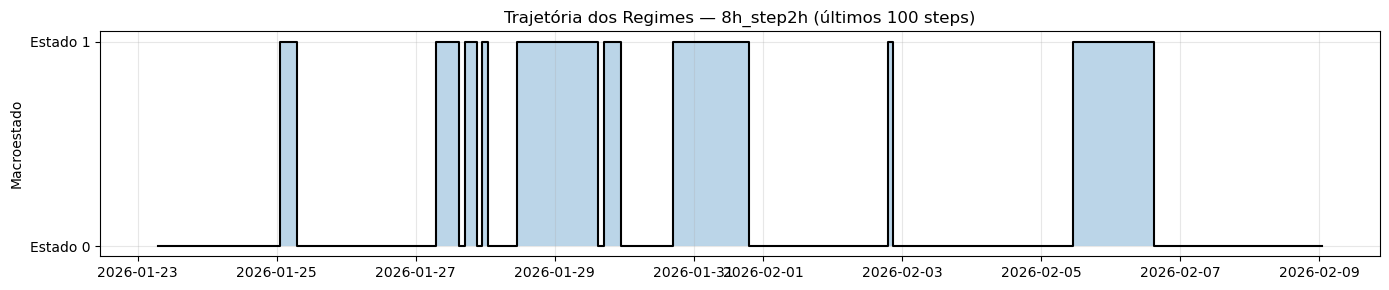


  8h_step4h


,empirical_mean_h,empirical_median_h,empirical_std_h,P_ii,tau_theoretical_h
cluster,,,,,
0,27.9,20.0,24.8,0.857143,28.000000
1,7.3,8.0,4.2,0.450331,7.277108


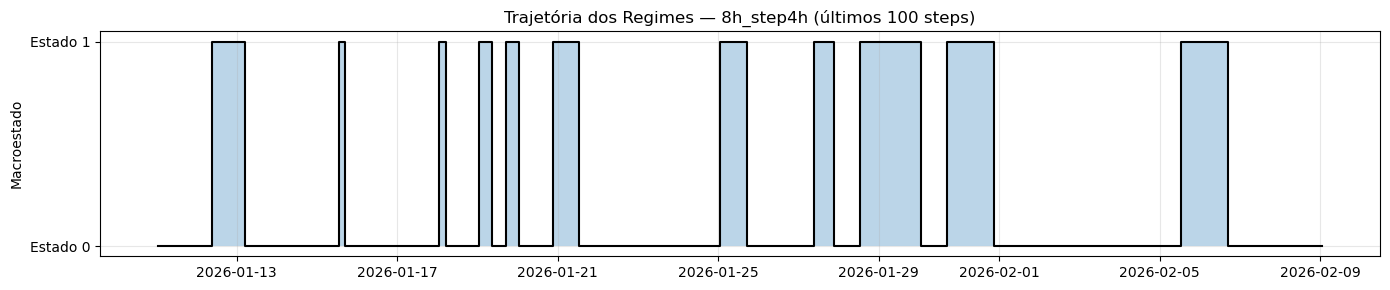


  8h_step8h


,empirical_mean_h,empirical_median_h,empirical_std_h,P_ii,tau_theoretical_h
cluster,,,,,
0,39.6,32.0,32.3,0.798354,39.673469
1,10.4,8.0,5.1,0.231771,10.413559


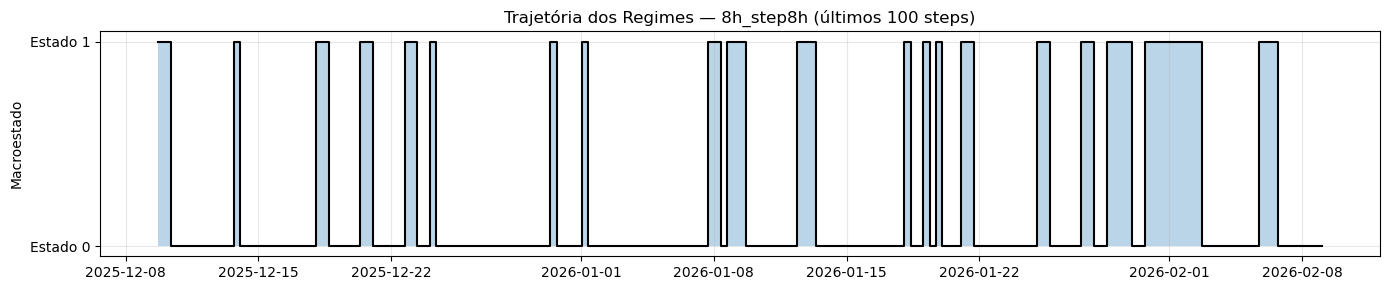


  12h_step1h


,empirical_mean_h,empirical_median_h,empirical_std_h,P_ii,tau_theoretical_h
cluster,,,,,
0,22.0,14.0,21.9,0.954532,21.993333
1,8.5,8.0,6.3,0.882203,8.489185


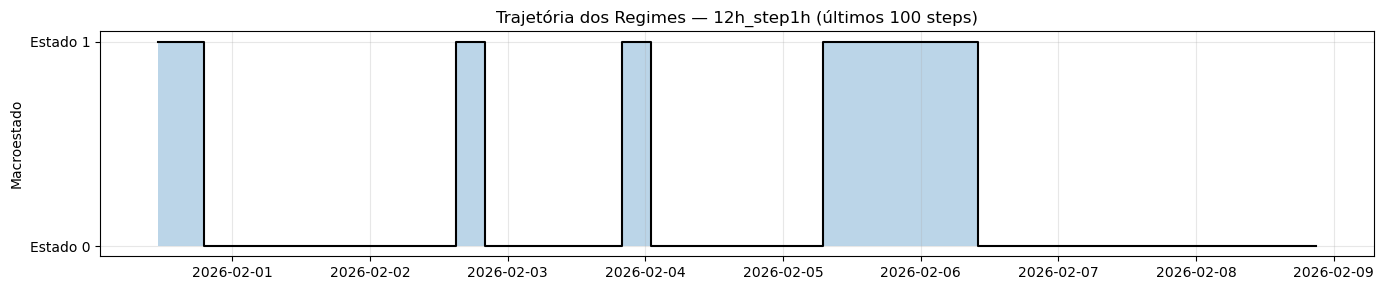


  12h_step2h


,empirical_mean_h,empirical_median_h,empirical_std_h,P_ii,tau_theoretical_h
cluster,,,,,
0,24.3,16.0,24.5,0.917812,24.334559
1,9.3,8.0,6.5,0.784925,9.299083


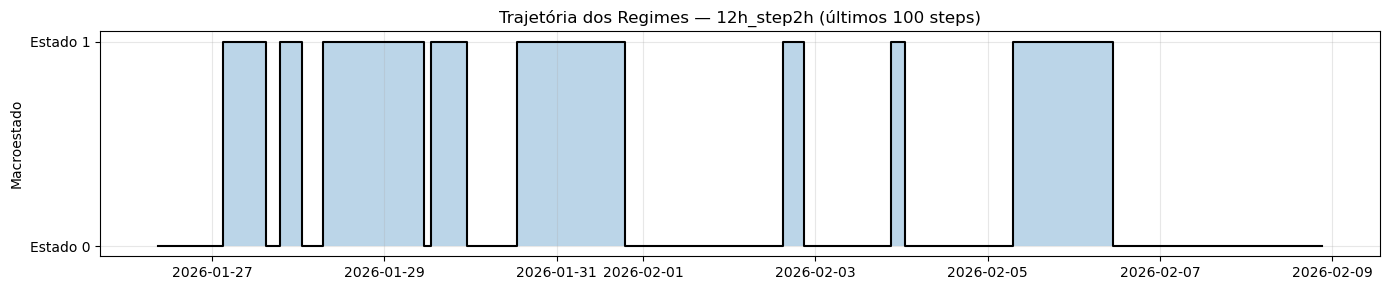


  12h_step6h


,empirical_mean_h,empirical_median_h,empirical_std_h,P_ii,tau_theoretical_h
cluster,,,,,
0,30.5,24.0,27.6,0.803431,30.523585
1,12.4,12.0,8.4,0.517045,12.423529


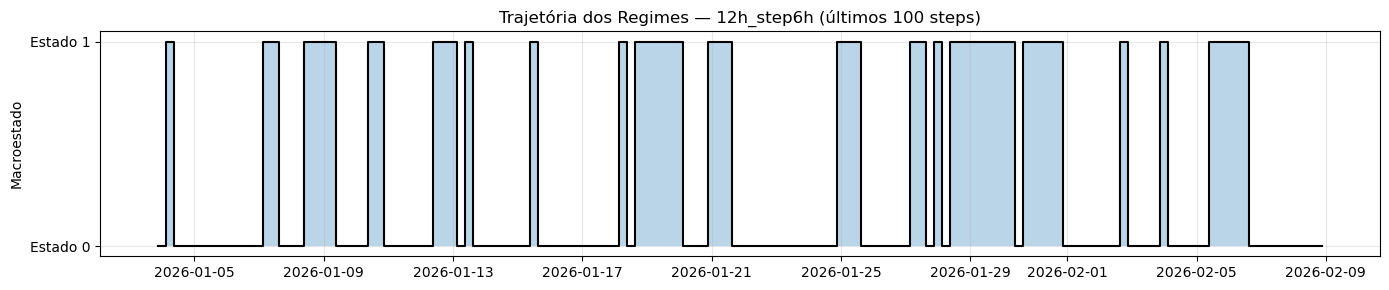


  12h_step12h


,empirical_mean_h,empirical_median_h,empirical_std_h,P_ii,tau_theoretical_h
cluster,,,,,
0,42.7,36.0,35.6,0.719512,42.782609
1,18.2,12.0,11.7,0.340659,18.200000


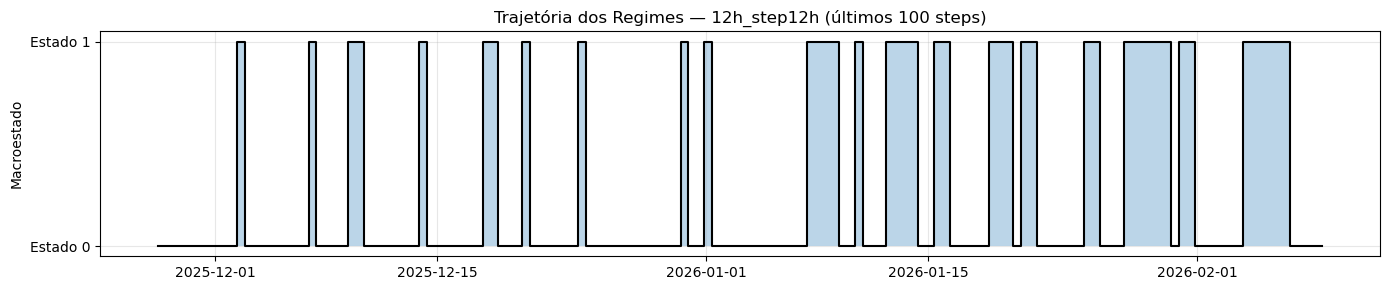


  24h_step1h


,empirical_mean_h,empirical_median_h,empirical_std_h,P_ii,tau_theoretical_h
cluster,,,,,
0,35.3,23.0,37.0,0.971711,35.349765
1,20.5,22.0,14.3,0.951155,20.473068


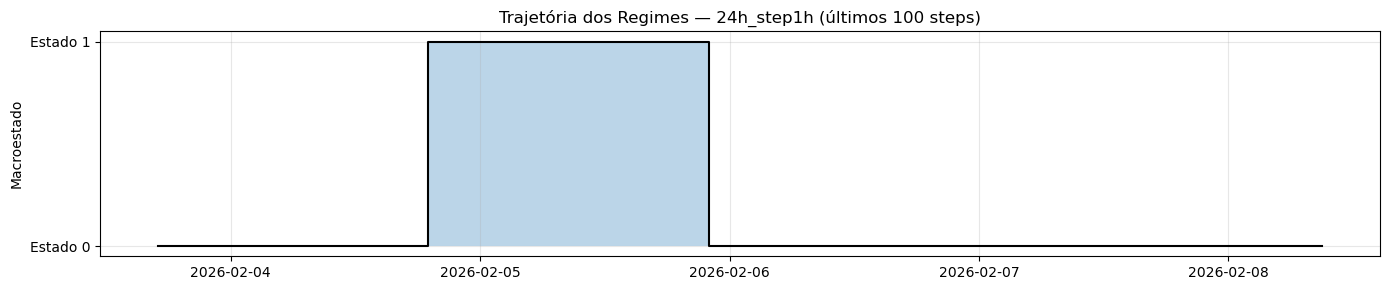


  24h_step6h


,empirical_mean_h,empirical_median_h,empirical_std_h,P_ii,tau_theoretical_h
cluster,,,,,
0,41.9,30.0,38.6,0.857316,42.050992
1,25.3,24.0,15.0,0.762416,25.254237


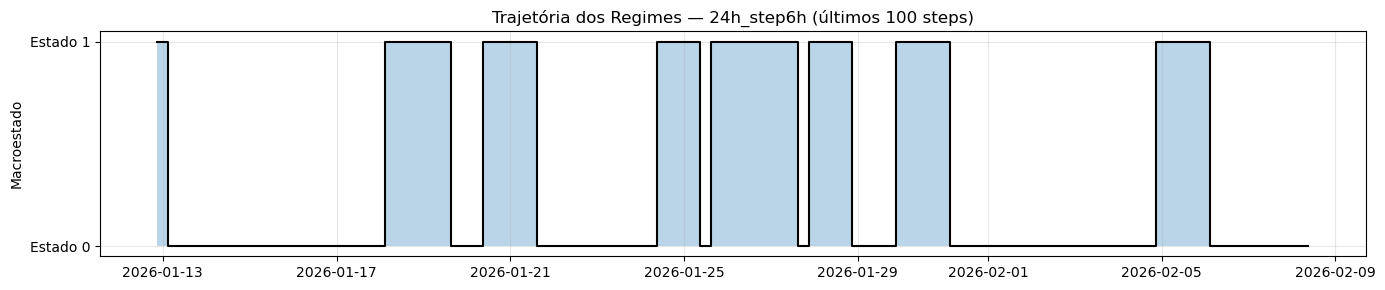


  24h_step12h


,empirical_mean_h,empirical_median_h,empirical_std_h,P_ii,tau_theoretical_h
cluster,,,,,
0,50.1,36.0,43.2,0.761062,50.222222
1,29.9,24.0,17.1,0.598923,29.919463


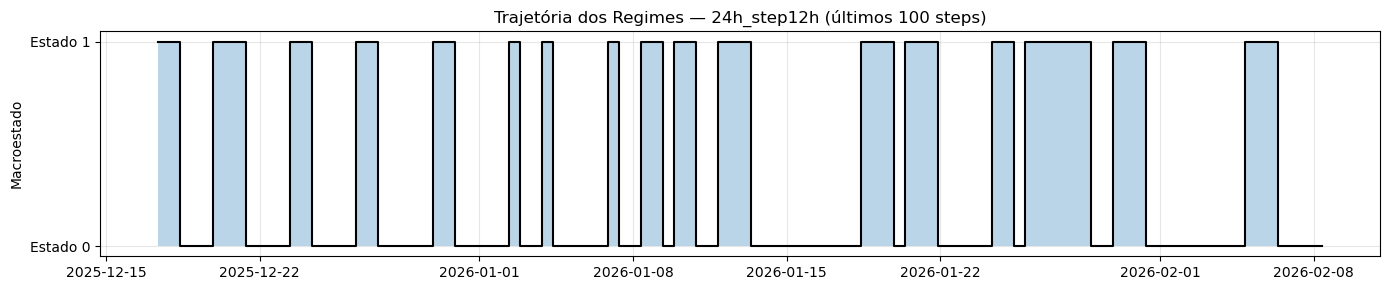


  24h_step24h


,empirical_mean_h,empirical_median_h,empirical_std_h,P_ii,tau_theoretical_h
cluster,,,,,
0,64.7,48.0,48.9,0.630293,64.916300
1,40.1,24.0,25.7,0.401575,40.105263


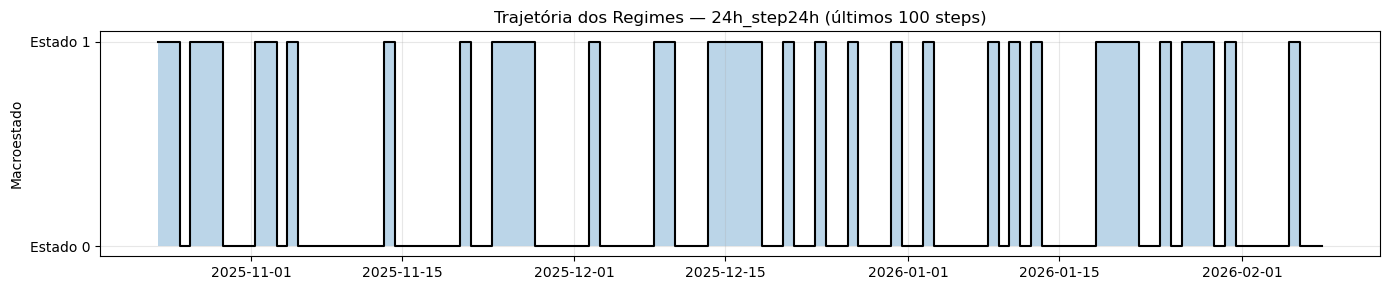

In [18]:
def dwell_time_analysis(r: dict) -> pd.DataFrame:
    """
    Calcula dwell times teórico e empírico a partir da saída de run_pipeline.
    """
    T = r['markov']
    step_hours = pd.Timedelta(r['step_size']).total_seconds() / 3600
    K = len(np.unique(r['labels']))

    # Theoretical
    diag_T = np.diag(T)
    tau_steps = 1 / (1 - diag_T + 1e-12) 
    tau_hours = tau_steps * step_hours

    # Empirical
    df_S = (
        r['features_df']
        .assign(cluster=r['labels'])
        .dropna(subset=['window_start', 'cluster'])
        .sort_values('window_start')
        .reset_index(drop=True)
    )
    df_S['block'] = (df_S['cluster'].diff().ne(0)).cumsum()

    dwell_stats = (
        df_S.groupby(['cluster', 'block'])
        .agg(n_steps=('cluster', 'count'))
        .reset_index()
    )
    dwell_stats['duration_hours'] = dwell_stats['n_steps'] * step_hours

    empirical = (
        dwell_stats.groupby('cluster')['duration_hours']
        .agg(['mean', 'median', 'std'])
        .round(1)
    )
    empirical.columns = ['empirical_mean_h', 'empirical_median_h', 'empirical_std_h']

    # Theoretical + Empirical
    summary = empirical.copy()
    summary['P_ii']          = diag_T
    summary['tau_theoretical_h'] = tau_hours

    return summary, dwell_stats


# Evaluate in each configuration
for (w, s) in CONFIGS:
    key = f"{w}_step{s}"
    print(f"\n{'='*50}\n  {key}\n{'='*50}")
    summary, dwell_stats = dwell_time_analysis(results[key])
    display(summary)

# Trajectories
    r = results[key]
    df_S = (
        r['features_df']
        .assign(cluster=r['labels'])
        .dropna(subset=['window_start', 'cluster'])
        .sort_values('window_start')
        .reset_index(drop=True)
    )
    K = len(np.unique(r['labels']))

    fig, ax = plt.subplots(figsize=(14, 3))
    subset = df_S.tail(100)
    ax.step(subset['window_start'], subset['cluster'], where='post', lw=1.5, color='black')
    ax.fill_between(subset['window_start'], subset['cluster'], step='post', alpha=0.3)
    ax.set_title(f'Trajetória dos Regimes — {key} (últimos 100 steps)')
    ax.set_yticks(range(K))
    ax.set_yticklabels([f'Estado {i}' for i in range(K)])
    ax.set_ylabel('Macroestado')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'../figures/trajectory_{key}.png', dpi=150)
    plt.show()

### **7.3 Teste formal da propriedade Markoviana**

A concordância entre $\tau$ teórico e $\tau$ empírico é condição necessária mas não suficiente 
para validar o tratamento markoviano. A hipótese central de uma cadeia de Markov de 
primeira ordem é a **propriedade de falta de memória**: a 
probabilidade de transição não depende do tempo já passado no estado atual.

Para uma cadeia de Markov de tempo discreto, os dwell times devem seguir uma 
distribuição geométrica — ou equivalentemente, uma distribuição exponencial no 
limite contínuo. Testamos essa hipótese via teste de Kolmogorov-Smirnov (KS) 
contra a distribuição exponencial ajustada.

- **p-value > 0.05**: não rejeita a exponencial $\rightarrow$ processo memoryless $\rightarrow$ 
  tratamento markoviano de primeira ordem é adequado
- **p-value < 0.05**: rejeita a exponencial $\rightarrow$ o sistema possui memória além 
  do que uma cadeia de Markov de primeira ordem captura

In [19]:

def test_markov_memoryless(dwell_stats: pd.DataFrame, step_hours: float) -> None:
    """
    Testa a propriedade memoryless via:
    1. Ajuste exponencial aos dwell times (KS test)
    2. Plot Q-Q exponencial
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for cluster_id, grp in dwell_stats.groupby('cluster'):
        durations = grp['duration_hours'].values

        # KS test vs exponential
        lambda_est = 1 / durations.mean()
        ks_stat, p_value = stats.kstest(
            durations,
            'expon',
            args=(0, 1 / lambda_est)
        )

        print(f"Cluster {cluster_id}: "
              f"mean={durations.mean():.1f}h | "
              f"KS stat={ks_stat:.3f} | "
              f"p-value={p_value:.4f} | "
              f"{'✓ memoryless' if p_value > 0.05 else '✗ tem memória'}")

        #  Q-Q Exponential plot 
        ax = axes[cluster_id]
        stats.probplot(durations, dist='expon', sparams=(0, durations.mean()), plot=ax)
        ax.set_title(f'Q-Q Exponencial — Cluster {cluster_id}\n'
                     f'KS p-value={p_value:.4f}')

    plt.suptitle('Teste de Memoryless — Dwell Times vs. Exponencial')
    plt.tight_layout()
    plt.savefig('../figures/memoryless_test.png', dpi=150)
    plt.show()


  8h_step1h
Cluster 0: mean=18.6h | KS stat=0.058 | p-value=0.0318 | ✗ tem memória
Cluster 1: mean=5.2h | KS stat=0.194 | p-value=0.0000 | ✗ tem memória


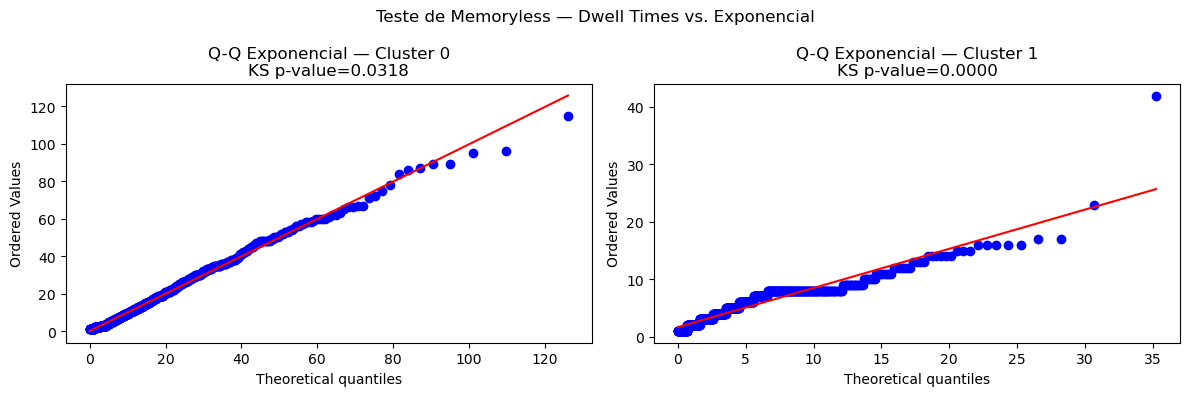


  8h_step2h
Cluster 0: mean=21.3h | KS stat=0.090 | p-value=0.0003 | ✗ tem memória
Cluster 1: mean=5.8h | KS stat=0.291 | p-value=0.0000 | ✗ tem memória


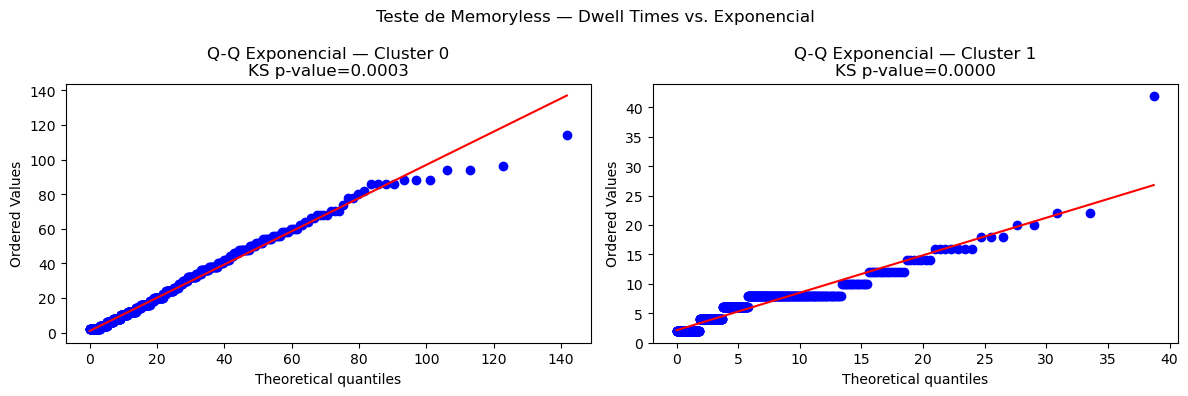


  8h_step4h
Cluster 0: mean=27.9h | KS stat=0.133 | p-value=0.0000 | ✗ tem memória
Cluster 1: mean=7.3h | KS stat=0.423 | p-value=0.0000 | ✗ tem memória


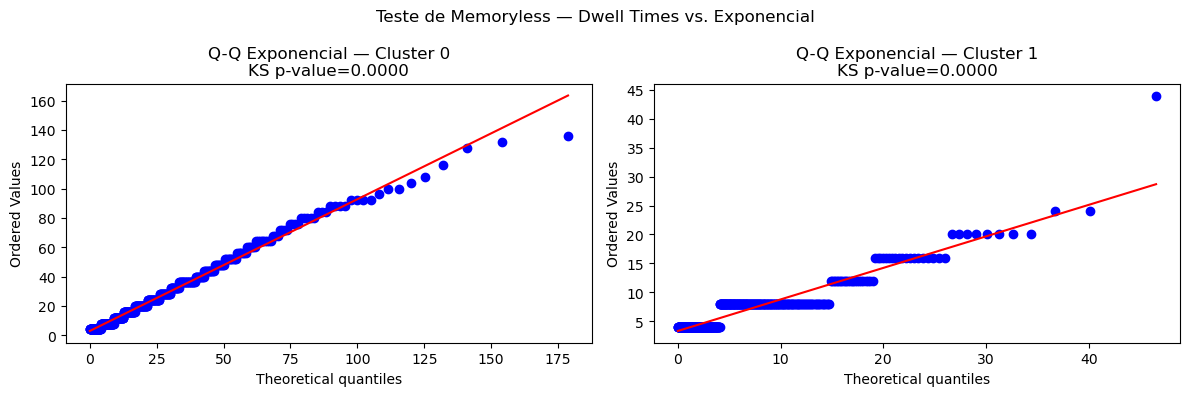


  8h_step8h
Cluster 0: mean=39.6h | KS stat=0.183 | p-value=0.0000 | ✗ tem memória
Cluster 1: mean=10.4h | KS stat=0.536 | p-value=0.0000 | ✗ tem memória


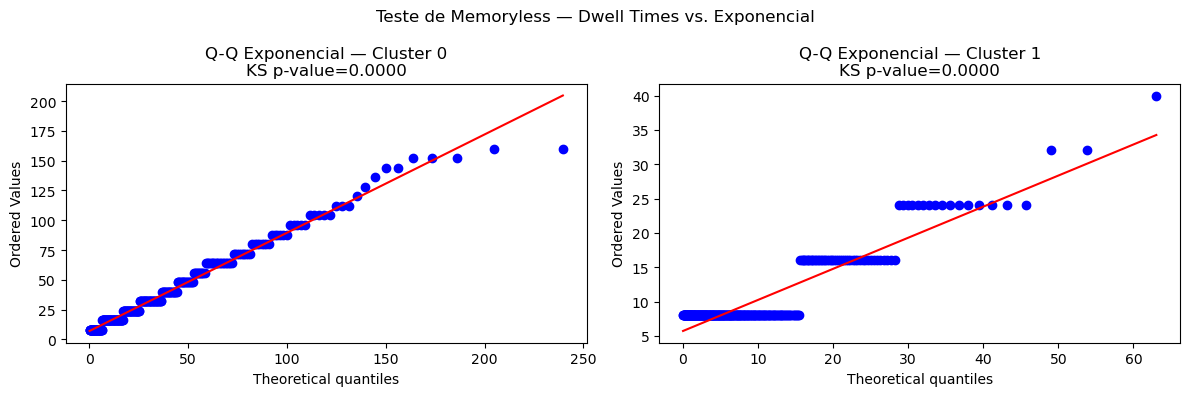


  12h_step1h
Cluster 0: mean=22.0h | KS stat=0.047 | p-value=0.1342 | ✓ memoryless
Cluster 1: mean=8.5h | KS stat=0.131 | p-value=0.0000 | ✗ tem memória


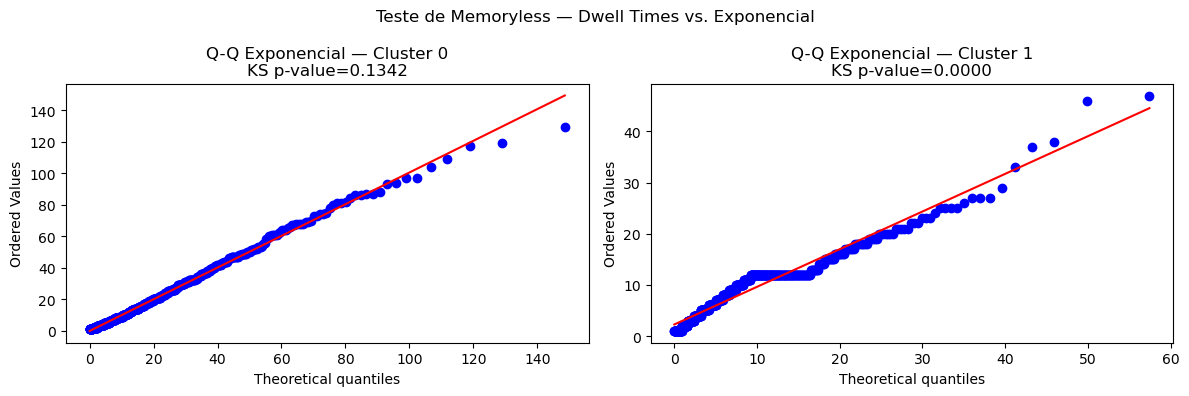


  12h_step2h
Cluster 0: mean=24.3h | KS stat=0.079 | p-value=0.0021 | ✗ tem memória
Cluster 1: mean=9.3h | KS stat=0.194 | p-value=0.0000 | ✗ tem memória


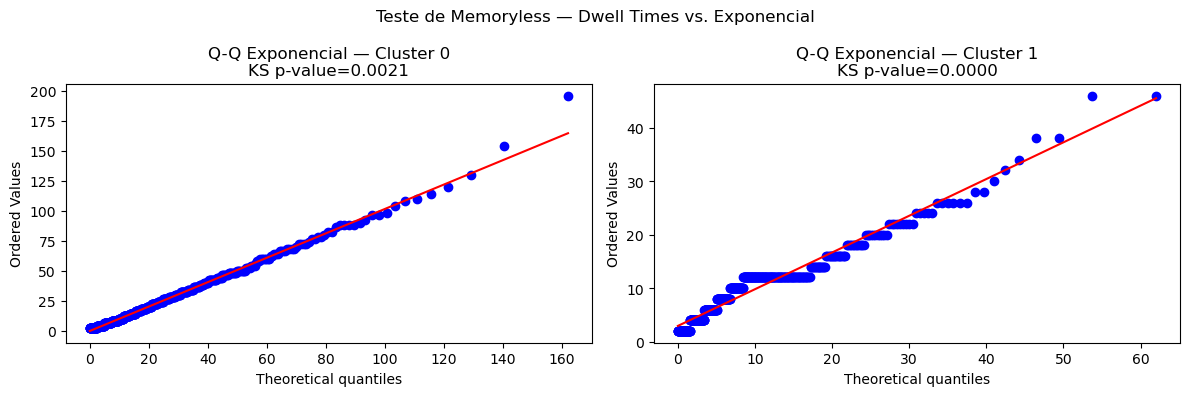


  12h_step6h
Cluster 0: mean=30.5h | KS stat=0.179 | p-value=0.0000 | ✗ tem memória
Cluster 1: mean=12.4h | KS stat=0.383 | p-value=0.0000 | ✗ tem memória


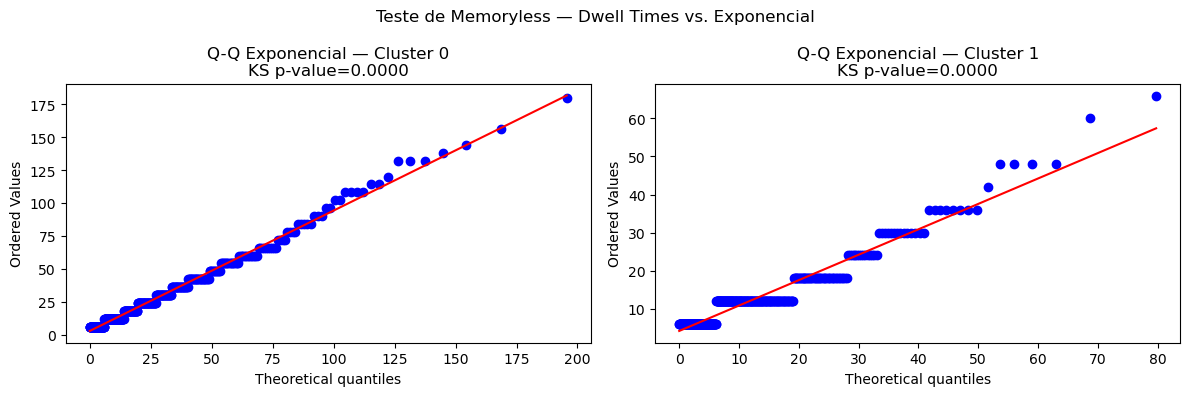


  12h_step12h
Cluster 0: mean=42.7h | KS stat=0.245 | p-value=0.0000 | ✗ tem memória
Cluster 1: mean=18.2h | KS stat=0.483 | p-value=0.0000 | ✗ tem memória


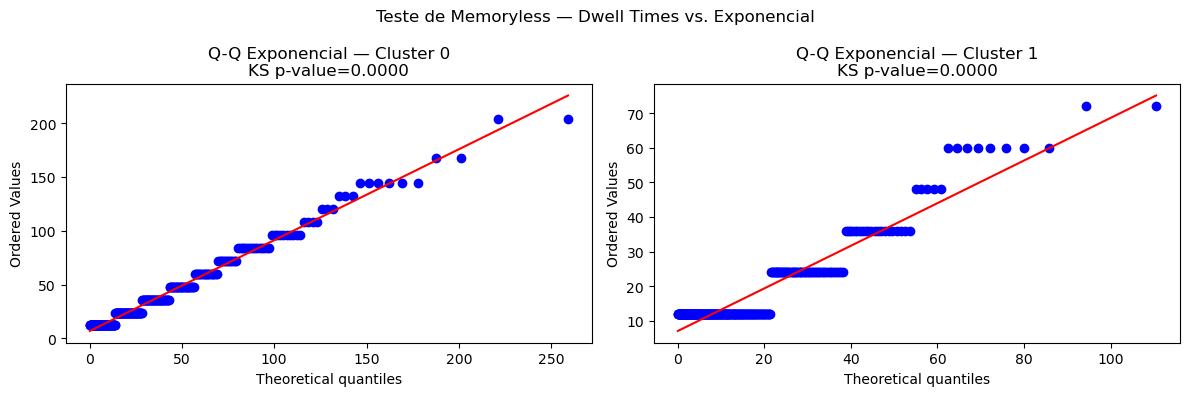


  24h_step1h
Cluster 0: mean=35.3h | KS stat=0.058 | p-value=0.1135 | ✓ memoryless
Cluster 1: mean=20.5h | KS stat=0.168 | p-value=0.0000 | ✗ tem memória


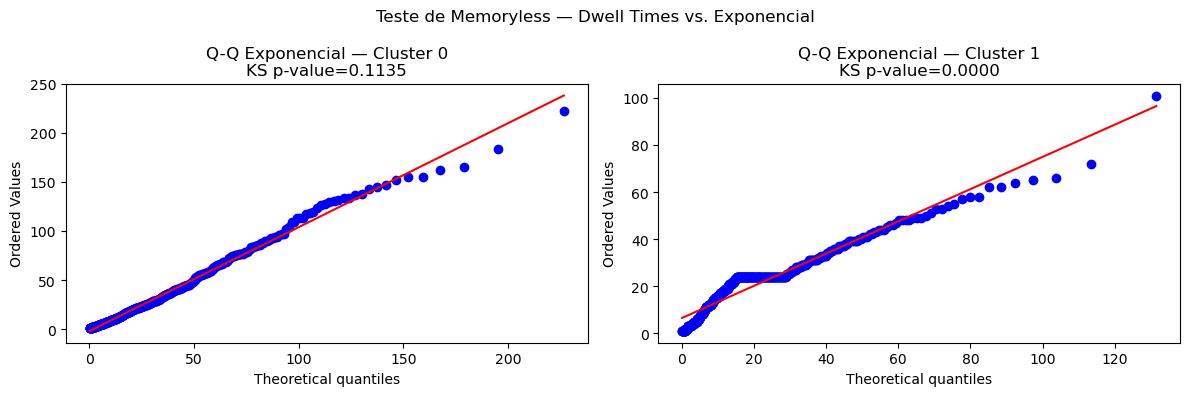


  24h_step6h
Cluster 0: mean=41.9h | KS stat=0.133 | p-value=0.0000 | ✗ tem memória
Cluster 1: mean=25.3h | KS stat=0.253 | p-value=0.0000 | ✗ tem memória


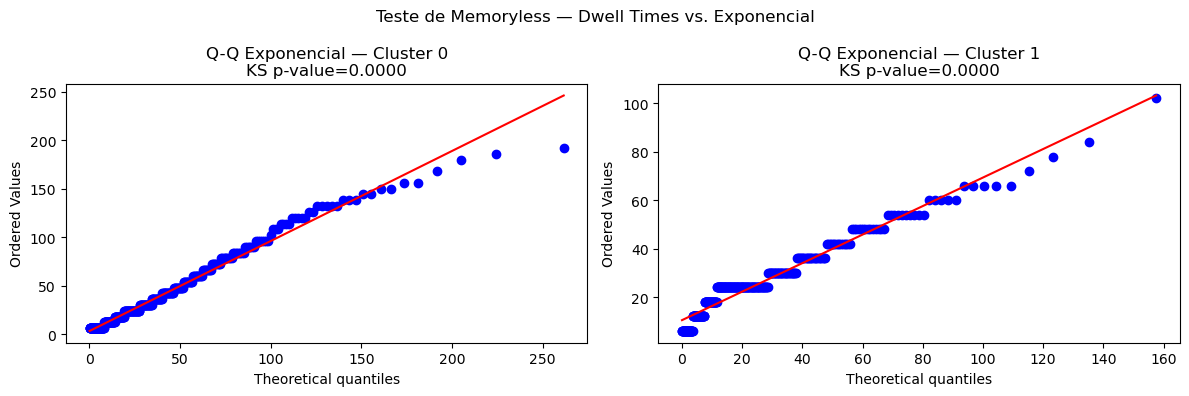


  24h_step12h
Cluster 0: mean=50.1h | KS stat=0.213 | p-value=0.0000 | ✗ tem memória
Cluster 1: mean=29.9h | KS stat=0.350 | p-value=0.0000 | ✗ tem memória


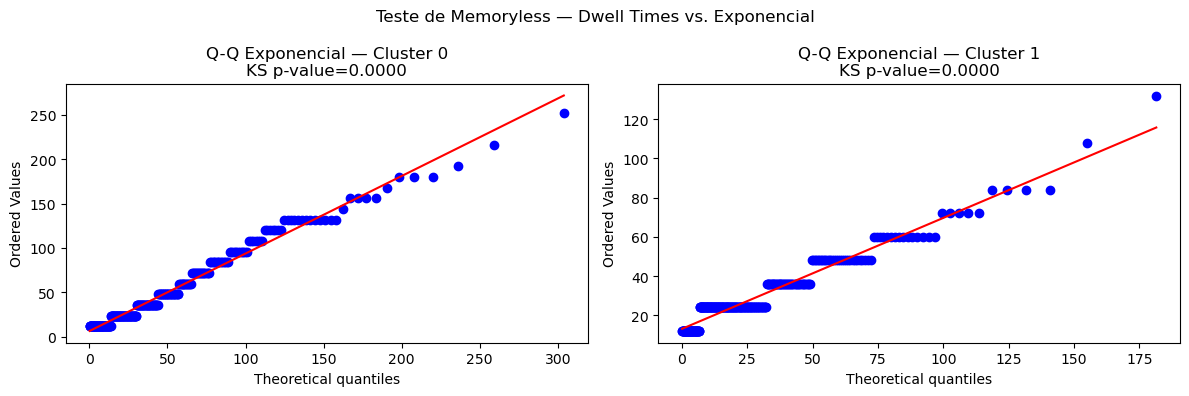


  24h_step24h
Cluster 0: mean=64.7h | KS stat=0.310 | p-value=0.0000 | ✗ tem memória
Cluster 1: mean=40.1h | KS stat=0.450 | p-value=0.0000 | ✗ tem memória


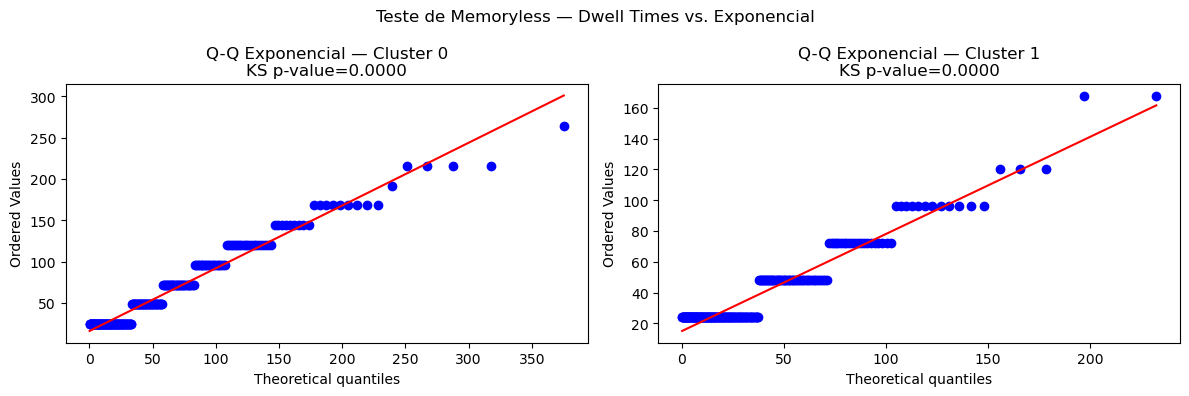

In [20]:
for (w, s) in CONFIGS:
    key = f"{w}_step{s}"
    print(f"\n{'='*50}\n  {key}\n{'='*50}")
    r = results[key]
    step_hours = pd.Timedelta(r['step_size']).total_seconds() / 3600
    _, dwell_stats = dwell_time_analysis(r)
    test_markov_memoryless(dwell_stats, step_hours)

O teste KS rejeita a hipótese exponencial na maior parte das configurações analisadas. Esse resultado sugere que os dwell times apresentam desvios sistemáticos em relação ao comportamento esperado para uma cadeia de Markov de primeira ordem ideal, em particular com ocorrência de episódios de quiescência longa mais frequentes do que o previsto por um modelo estritamente memoryless.

Entretanto, essa evidência deve ser interpretada com cautela. Em uma cadeia de Markov de tempo discreto, a distribuição teoricamente esperada para os dwell times é geométrica em número de passos, e não exponencial contínua em horas. Como, no presente pipeline, os dwell times são quantizados em múltiplos fixos do step, o teste KS contra a exponencial contínua tende a ser artificialmente sensível, sobretudo nas configurações com menor overlap e para o ****cluster 1****, cujos tempos típicos de permanência são curtos.

Nesse sentido, as configurações com maior resolução temporal e maior sobreposição entre janelas, em particular ****12h/1h**** e ****24h/1h****, fornecem as estimativas mais confiáveis. Nesses casos, o ****cluster 0**** apresenta compatibilidade estatística com o comportamento memoryless ($p > 0.05$), enquanto o ****cluster 1**** continua exibindo desvios mais pronunciados.

Apesar disso, o framework markoviano de primeira ordem permanece uma aproximação útil para a dinâmica típica do sistema, uma vez que os tempos médios de residência teóricos e empíricos concordam de forma consistente em todas as configurações analisadas. Assim, o quadro que emerge é o de uma dinâmica efetiva aproximadamente markoviana em nível médio, mas com desvios nas caudas que podem refletir correlações temporais de maior alcance.

## **8. Desempenho da CNN-1D por configuração**

Retreinamos a CNN-1D para cada configuração de janela e comparamos AUC e F1 macro. Uma queda suave e monotônica com a redução do tamanho de janela é esperada — janelas menores contêm menos eventos, reduzindo o sinal estatístico disponível para o classificador.

In [21]:
def make_temporal_sequences(X, y, times, seq_len=8, horizon=1):
    X_seq, y_seq, t_seq = [], [], []
    n_steps = len(X)
    for end_idx in range(seq_len - 1, n_steps - horizon):
        start_idx = end_idx - seq_len + 1
        target_idx = end_idx + horizon
        X_seq.append(X[start_idx:end_idx + 1])
        y_seq.append(y[target_idx])
        t_seq.append(times.iloc[target_idx])
    return np.array(X_seq), np.array(y_seq), pd.Series(t_seq)


def build_and_train_cnn(X_train, y_train, X_val, y_val, seq_len, n_features, n_classes):
    model = keras.Sequential([
        keras.layers.Input(shape=(seq_len, n_features)),
        keras.layers.Conv1D(filters=128, kernel_size=3, activation="relu"),
        keras.layers.GlobalMaxPooling1D(),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=100, batch_size=32, verbose=0)
    return model


def train_eval_cnn(features_df, labels, seq_len=8, horizon=1) -> dict:
    """
    Replica o pipeline do notebook principal:
    prepare_X → make_temporal_sequences → split temporal → CNN.
    """
    drop_cols = ["cluster", "window_start", "window_end", "window_label"]

    df_seq = (
        features_df
        .assign(cluster=labels)
        .dropna(subset=["window_start", "cluster"])
        .sort_values("window_start")
        .reset_index(drop=True)
        .copy()
    )

    le = LabelEncoder()
    y = le.fit_transform(df_seq["cluster"])

    feature_cols = [c for c in df_seq.columns if c not in drop_cols]
    X_tab = df_seq[feature_cols].copy()
    t_tab = df_seq["window_start"]

    imputer = SimpleImputer(strategy="median")
    scaler  = StandardScaler()
    X_imp    = imputer.fit_transform(X_tab)
    X_scaled = scaler.fit_transform(X_imp)

    X_seq, y_seq, t_seq = make_temporal_sequences(X_scaled, y, t_tab,
                                                   seq_len=seq_len, horizon=horizon)

    # Split temporal (60/20/20)
    t_train = t_seq.quantile(0.6)
    t_val   = t_seq.quantile(0.8)
    train_mask = t_seq < t_train
    val_mask   = (t_seq >= t_train) & (t_seq < t_val)
    test_mask  = t_seq >= t_val

    X_train, y_train = X_seq[train_mask], y_seq[train_mask]
    X_val,   y_val   = X_seq[val_mask],   y_seq[val_mask]
    X_test,  y_test  = X_seq[test_mask],  y_seq[test_mask]

    n_features = X_train.shape[2]
    n_classes  = len(np.unique(y_seq))

    model   = build_and_train_cnn(X_train, y_train, X_val, y_val,
                                   seq_len, n_features, n_classes)
    y_prob  = model.predict(X_test, verbose=0)
    y_pred  = np.argmax(y_prob, axis=1)

    # ROC macro-average para qualquer k
    from sklearn.preprocessing import label_binarize
    classes = np.unique(y_seq)
    y_test_bin = label_binarize(y_test, classes=classes)

    if len(classes) == 2:
        # binário — roc_curve direto
        fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_prob[:, 1])
        roc_auc = auc(fpr, tpr)
    else:
        # multiclasse — macro average das curvas ROC
        from sklearn.metrics import roc_auc_score
        fpr, tpr = {}, {}
        for c in range(len(classes)):
            fpr[c], tpr[c], _ = roc_curve(y_test_bin[:, c], y_prob[:, c])
        # macro: média simples das AUCs por classe
        roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')
        # para o plot usa a classe mais frequente como representativa
        fpr, tpr = fpr[0], tpr[0]

    return {
        "auc":      roc_auc,
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "accuracy": accuracy_score(y_test, y_pred),
        "fpr": fpr, "tpr": tpr,
        "y_test": y_test, "y_pred": y_pred,
        "class_names": [str(c) for c in le.classes_],
    }

In [22]:
# Train the CNN for each configuration

cnn_results = {}
for (w, s) in CONFIGS:
    key = f"{w}_step{s}"
    print(f"Treinando CNN: window={w}, step={s} ...", end=" ")
    r = results[key]
    cnn_results[key] = train_eval_cnn(r["features_df"], r["labels"])
    cr = cnn_results[key]
    print(f"AUC={cr['auc']:.3f} | F1 macro={cr['f1_macro']:.3f}")

Treinando CNN: window=8h, step=1h ... 

E0000 00:00:1773599958.265105   15838 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


AUC=0.817 | F1 macro=0.801
Treinando CNN: window=8h, step=2h ... AUC=0.651 | F1 macro=0.635
Treinando CNN: window=8h, step=4h ... AUC=0.547 | F1 macro=0.539
Treinando CNN: window=8h, step=8h ... AUC=0.486 | F1 macro=0.472
Treinando CNN: window=12h, step=1h ... AUC=0.870 | F1 macro=0.846
Treinando CNN: window=12h, step=2h ... AUC=0.724 | F1 macro=0.693
Treinando CNN: window=12h, step=6h ... AUC=0.543 | F1 macro=0.485
Treinando CNN: window=12h, step=12h ... AUC=0.485 | F1 macro=0.499
Treinando CNN: window=24h, step=1h ... AUC=0.947 | F1 macro=0.913
Treinando CNN: window=24h, step=6h ... AUC=0.633 | F1 macro=0.591
Treinando CNN: window=24h, step=12h ... AUC=0.565 | F1 macro=0.555
Treinando CNN: window=24h, step=24h ... AUC=0.516 | F1 macro=0.506


In [23]:
summary_rows = []
for (w, s) in CONFIGS:
    key = f"{w}_step{s}"
    r  = results[key]
    cr = cnn_results[key]
    overlap = (1 - pd.Timedelta(s) / pd.Timedelta(w)) * 100
    summary_rows.append({
        'Window (h)': w,
        'Step (h)': s,
        'Overlap (%)': f'{overlap:.0f}%',
        'N janelas': r['n_windows'],
        'Silhouette': f"{r['silhouette']:.3f}",
        'AUC': f"{cr['auc']:.3f}",
        'F1 macro': f"{cr['f1_macro']:.3f}",
        'Accuracy': f"{cr['accuracy']:.3f}",
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

,Window (h),Step (h),Overlap (%),N janelas,Silhouette,AUC,F1 macro,Accuracy
0,8h,1h,88%,14600,0.336,0.817,0.801,0.862
1,8h,2h,75%,7293,0.338,0.651,0.635,0.774
2,8h,4h,50%,3654,0.344,0.547,0.539,0.686
3,8h,8h,0%,1843,0.349,0.486,0.472,0.676
4,12h,1h,92%,18299,0.273,0.870,0.846,0.872
5,12h,2h,83%,9154,0.275,0.724,0.693,0.750
6,12h,6h,50%,3038,0.271,0.543,0.485,0.581
7,12h,12h,0%,1522,0.266,0.485,0.499,0.584
8,24h,1h,96%,23802,0.205,0.947,0.913,0.920
9,24h,6h,75%,3965,0.204,0.633,0.591,0.615


## **9. Conclusão**

A análise de sensibilidade mostra que o pipeline proposto é robusto frente às diferentes escolhas de tamanho de janela e passo da janela deslizante para os eventos sísmicos da região de subducção da Indonésia. Em todo o grid de configurações testado, a estrutura de clusterização preserva de forma consistente a emergência de dois macroestados estatística e fisicamente distintos.

O **cluster 0** está associado a um **regime basal**, caracterizado por menores taxas diárias de sismicidade e atividade espacialmente mais localizada, enquanto o **cluster 1** corresponde a um **regime ativo**, marcado por taxas sísmicas mais elevadas e por uma distribuição espacial mais dispersa ao longo da zona de subducção. A persistência dessa interpretação ao longo das diferentes configurações indica que a separação em dois regimes não é um artefato trivial do procedimento de janelamento.

Do ponto de vista dinâmico, as matrizes de transição revelam uma assimetria clara entre os dois estados. O regime basal é sistematicamente o mais persistente, constituindo o estado mais claramente metaestável do sistema. Já o regime ativo apresenta caráter metaestável apenas nas configurações com maior resolução temporal e maior sobreposição entre janelas, tornando-se progressivamente mais transitório à medida que a sobreposição é reduzida. Esse comportamento é compatível com a interpretação física de episódios ativos como excitações temporárias sobre um fundo basal mais persistente.

A concordância entre os tempos médios de residência empíricos e teóricos mostra que uma descrição markoviana de primeira ordem constitui uma aproximação coarse-grained útil para a dinâmica típica do sistema. Por outro lado, os desvios observados nos testes de dwell times, sobretudo nas caudas, indicam que a dinâmica não é estritamente memoryless. Assim, a sismicidade da região da Indonésia pode ser descrita, em primeira aproximação, por um processo efetivo de dois estados, preservando ainda indícios de correlações temporais de maior alcance.

Em conjunto, os resultados sustentam a interpretação de que a atividade sísmica na região analisada se organiza em dois regimes dinâmicos efetivos: um estado basal persistente e um estado ativo mais intermitente. Esse quadro fornece uma base consistente para desenvolvimentos futuros, incluindo extensões semi-Markovianas, processos de renovação com memória e descrições efetivas mais gerais para a dinâmica coarse-grained do sistema.